<a href="https://colab.research.google.com/github/jhasankbharadwaj/carprice_prediction/blob/main/Dynamic_Pricing_Suggestion_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** T V M V C Jhasank Bharadwaj

**Student ID:** 2025AG05622

| **Dataset** | Retail Supply Chain Sales |

| **Task** | Regression — Predicting Sales |

| **Primary Metrics** | R2 / Adjusted R2 / RMSE / MAE |

---
> **Notebook outline**
> 1. Imports
> 2. Data loading and validation
> 3. Exploratory Data Analysis
> 4. Preprocessing and feature engineering
> 5. Baseline — Linear Regression (from scratch)
> 6. MLP — Multi-Layer Perceptron (from scratch)
> 7. Evaluation and comparison
> 8. Conclusion





**1. Imports**

In [85]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

print('✓ Libraries imported successfully')


✓ Libraries imported successfully


In [86]:
data= pd.read_csv('/content/Retail-Supply-Chain-Sales-Dataset.csv', encoding='latin1')
data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.00,41.91
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.94,3,0.00,219.58
2,3,CA-2016-138688,06-12-2016,06-12-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.62,2,0.00,6.87
3,4,US-2015-108966,10-11-2015,10-11-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.58,5,0.45,-383.03
4,5,US-2015-108966,10-11-2015,10-11-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.37,2,0.20,2.52


# **3. Exploratory Data Analysis**

In [87]:
data.shape

(9994, 23)

In [88]:
data.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858022,3.789574,0.156203,28.656973
std,2885.163629,32063.693350,623.245131,2.225110,0.206452,234.260203
min,1.000000,1040.000000,0.440000,1.000000,0.000000,-6599.980000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.730000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.665000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.360000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.980000


In [89]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Row ID               9994 non-null   int64  
 1   Order ID             9994 non-null   object 
 2   Order Date           9994 non-null   object 
 3   Ship Date            9994 non-null   object 
 4   Ship Mode            9994 non-null   object 
 5   Customer ID          9994 non-null   object 
 6   Customer Name        9994 non-null   object 
 7   Segment              9994 non-null   object 
 8   Country              9994 non-null   object 
 9   City                 9994 non-null   object 
 10  State                9994 non-null   object 
 11  Postal Code          9994 non-null   int64  
 12  Region               9994 non-null   object 
 13  Retail Sales People  9994 non-null   object 
 14  Product ID           9994 non-null   object 
 15  Category             9994 non-null   o

In [90]:
col_name=data.columns


In [91]:
for i in data.columns:
    print ("number of unique :{}\n{}\n uniquevalues \n{}".format(i,data[i].nunique(),data[i].unique()))
    print ("---------------------- \n")

number of unique :Row ID
9994
 uniquevalues 
[   1    2    3 ... 9992 9993 9994]
---------------------- 

number of unique :Order ID
5009
 uniquevalues 
['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966' ... 'CA-2014-110422'
 'CA-2017-121258' 'CA-2017-119914']
---------------------- 

number of unique :Order Date
1237
 uniquevalues 
['11-08-2016' '06-12-2016' '10-11-2015' ... '06-03-2016' '04-12-2015'
 '21-01-2014']
---------------------- 

number of unique :Ship Date
1215
 uniquevalues 
['11-11-2016' '06-12-2016' '10-11-2015' ... '23-05-2015' '23-01-2014'
 '03-03-2017']
---------------------- 

number of unique :Ship Mode
4
 uniquevalues 
['Second Class' 'Standard Class' 'First Class' 'Same Day']
---------------------- 

number of unique :Customer ID
793
 uniquevalues 
['CG-12520' 'DV-13045' 'SO-20335' 'BH-11710' 'AA-10480' 'IM-15070'
 'HP-14815' 'PK-19075' 'AG-10270' 'ZD-21925' 'KB-16585' 'SF-20065'
 'EB-13870' 'EH-13945' 'TB-21520' 'MA-17560' 'GH-14485' 'SN-20710'
 'LC-16930' 'RA-1

**ploting the target variable to understand the skewness and density of the target**

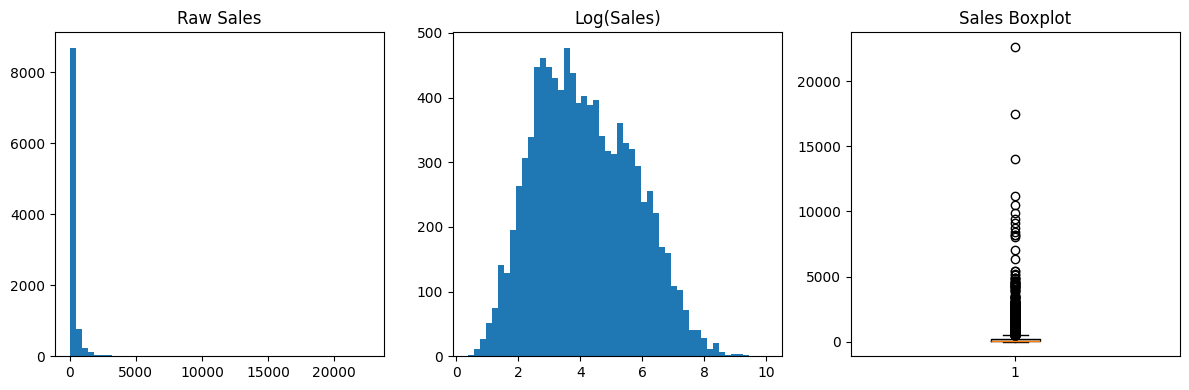

In [92]:


fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(data['Sales'], bins=50)
ax[0].set_title("Raw Sales")

log_sales = np.log1p(data['Sales'])
ax[1].hist(log_sales, bins=50)
ax[1].set_title("Log(Sales)")

ax[2].boxplot(data['Sales'])
ax[2].set_title("Sales Boxplot")

plt.tight_layout()
plt.show()

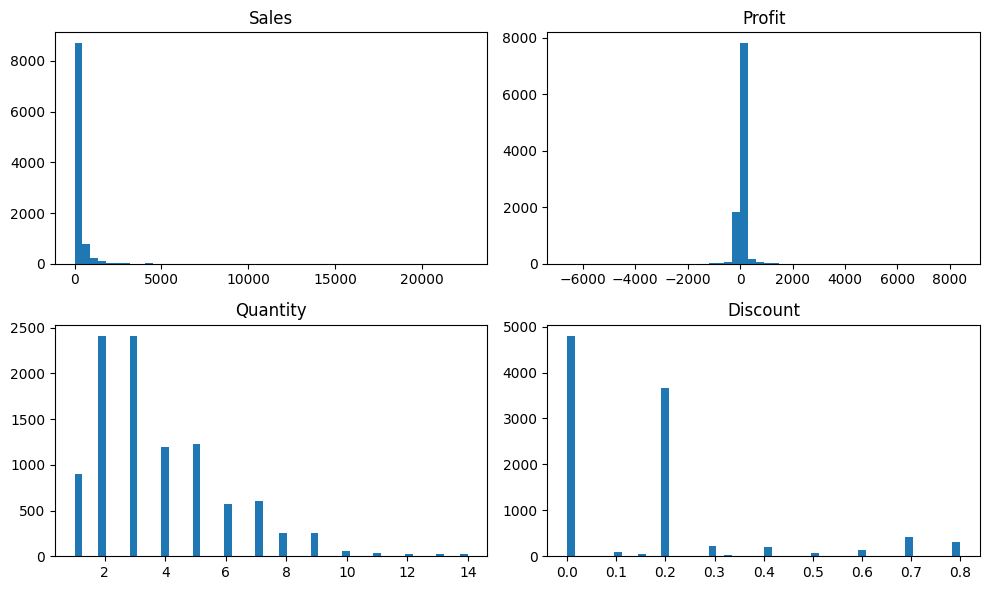

In [93]:
import matplotlib.pyplot as plt

data_numerical = data.select_dtypes(include=['number'])

cols = ['Sales', 'Profit', 'Quantity', 'Discount']

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax = ax.flatten()

for i, col in enumerate(cols):
    if col in data_numerical.columns:
        ax[i].hist(data_numerical[col], bins=50)
        ax[i].set_title(col)

plt.tight_layout()
plt.show()

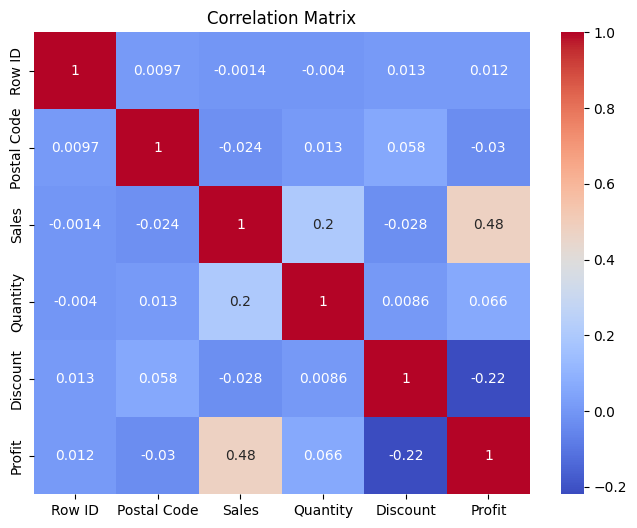

In [94]:
num_cols = data.select_dtypes(include='number')

# Correlation
corr = num_cols.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()
#from this we can understand that profit is highly corelated.

# **Preprocessing and feature engineering**




*These columns are identifiers or near-unique attributes (high cardinality), so they don’t carry generalizable patterns—models tend to memorize them rather than learn relationships.
They introduce noise and overfitting, especially in ML/DL models, because each value behaves like a unique key instead of a meaningful feature.
Some (like Order ID, Customer ID, Product ID) can also cause data leakage or artificial correlations, while Country has no variance, making it statistically useless.*

In [95]:
# ── 4.1 Drop identifier / leakage columns ────────────────────────────────
drop_cols = ['Row ID','Order ID','Customer ID','Customer Name',
             'Product ID','Product Name','Country','Postal Code']
data = data.drop([c for c in drop_cols if c in data.columns], axis=1)



*Extracting the year from dates helps the model notice overall trends, like how things change from one year to another. But using only the year can miss important details, so adding features like month or day often helps the model learn better patterns.*

In [96]:
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst=True, errors='coerce')
data['Ship Date']  = pd.to_datetime(data['Ship Date'],  dayfirst=True, errors='coerce')
data['order_year']     = data['Order Date'].dt.year
data['order_month']    = data['Order Date'].dt.month
data['shipping_delay'] = (data['Ship Date'] - data['Order Date']).dt.days
data.drop(['Order Date', 'Ship Date'], axis=1, inplace=True)

In [97]:
#as profit is highly corelated to sales we need to drop .

# **Train test split**

In [98]:
y = data['Sales'].values.astype(np.float64)
X = data.drop(['Sales', 'Profit'], axis=1, errors='ignore')
print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]:,}')


Features: 14  |  Samples: 9,994


In [99]:
X.describe(include='all')

X.shape

(9994, 14)

In [100]:
data_cat=X.select_dtypes(include=['object'])
data_numerical=X.select_dtypes(exclude=['object'])
print('data_cat columns',data_cat.columns,'\n')
print('data_numerical columns',data_numerical.columns)

data_cat columns Index(['Ship Mode', 'Segment', 'City', 'State', 'Region',
       'Retail Sales People', 'Category', 'Sub-Category', 'Returned'],
      dtype='object') 

data_numerical columns Index(['Quantity', 'Discount', 'order_year', 'order_month', 'shipping_delay'], dtype='object')


In [101]:
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train_raw.shape[0]:,}  |  Test: {X_test_raw.shape[0]:,}')

Train: 7,995  |  Test: 1,999


# **3. Encode categorical variables**

*Different categorical features have different characteristics, so using a single encoding method for all can either lose information or create too many unnecessary features.
Applying multiple encoding techniques ensures each feature is represented efficiently while improving model performance and avoiding issues like dimensional explosion.*

In [102]:
X_tr = X_train_raw.copy()
X_te = X_test_raw.copy()

city_freq    = X_tr['City'].value_counts()
X_tr['City'] = X_tr['City'].map(city_freq)
X_te['City'] = X_te['City'].map(city_freq).fillna(0)

# FIX: handle both 'No' and 'Not' variants
print('Returned unique values:', X_tr['Returned'].unique())
X_tr['Returned'] = X_tr['Returned'].map({'Yes': 1, 'No': 0, 'Not': 0}).fillna(0)
X_te['Returned'] = X_te['Returned'].map({'Yes': 1, 'No': 0, 'Not': 0}).fillna(0)

ohe_cols = ['Ship Mode','Segment','Region','Category','Retail Sales People','State','Sub-Category']
ohe_cols = [c for c in ohe_cols if c in X_tr.columns]
X_tr = pd.get_dummies(X_tr, columns=ohe_cols, drop_first=True)
X_te = pd.get_dummies(X_te, columns=ohe_cols, drop_first=True)
X_tr, X_te = X_tr.align(X_te, join='left', axis=1, fill_value=0)
print(f'After encoding: {X_tr.shape[1]} features')

# ── 4.6 Scale ─────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_tr).astype(np.float64)
X_test  = scaler.transform(X_te).astype(np.float64)

# ── 4.7 Log-transform target (CRITICAL FIX) ───────────────────────────────
Y_train_log = np.log1p(Y_train)
Y_test_log  = np.log1p(Y_test)
print(f'Target (log): mean={Y_train_log.mean():.3f}, std={Y_train_log.std():.3f}')
print('log1p applied to target. This is passed to fit() — not the raw Sales values.')

Returned unique values: ['Not' 'Yes']
After encoding: 84 features
Target (log): mean=4.158, std=1.588
log1p applied to target. This is passed to fit() — not the raw Sales values.


In [103]:
X_train.shape

(7995, 84)

**Model Training**

In [104]:
class BaselineRegressionModel:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.weights      = None
        self.bias         = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights      = np.zeros(n_features)
        self.bias         = 0.0
        self.loss_history = []
        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            loss   = float(np.mean((y_pred - y) ** 2))
            if np.isnan(loss) or np.isinf(loss):
                print(f'  WARNING: loss={loss} at iter {i+1}, stopping')
                break
            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db
            self.loss_history.append(loss)
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [105]:
# ── LR sweep (Linear Regression) ─────────────────────────────────────────
print('Learning rate sweep — Linear Regression (200 iters):')
print(f'{"LR":<10} {"Start loss":>12} {"End loss":>12}')
print('-' * 36)
best_lr_lin, best_end_lin = 0.01, np.inf
for test_lr in [0.001, 0.01, 0.05, 0.1]:
    w = np.zeros(X_train.shape[1]); b = 0.0; losses = []
    for _ in range(200):
        yp   = np.dot(X_train, w) + b
        loss = float(np.mean((yp - Y_train_log) ** 2))
        losses.append(loss)
        if np.isnan(loss): break
        dw = (2/len(Y_train_log)) * np.dot(X_train.T, (yp - Y_train_log))
        db = (2/len(Y_train_log)) * np.sum(yp - Y_train_log)
        w -= test_lr * dw; b -= test_lr * db
    end = losses[-1] if not np.isnan(losses[-1]) else np.inf
    print(f'{test_lr:<10} {losses[0]:>12.4f} {end:>12.4f}')
    if end < best_end_lin:
        best_end_lin = end; best_lr_lin = test_lr
print(f'Chosen LR: {best_lr_lin}')

Learning rate sweep — Linear Regression (200 iters):
LR           Start loss     End loss
------------------------------------
0.001           19.8088       9.3268
0.01            19.8088       1.0709
0.05            19.8088       1.0566
0.1             19.8088       1.0564
Chosen LR: 0.1


Training time : 0.77s
Loss          : 19.8088 -> 1.0564
Converged     : True


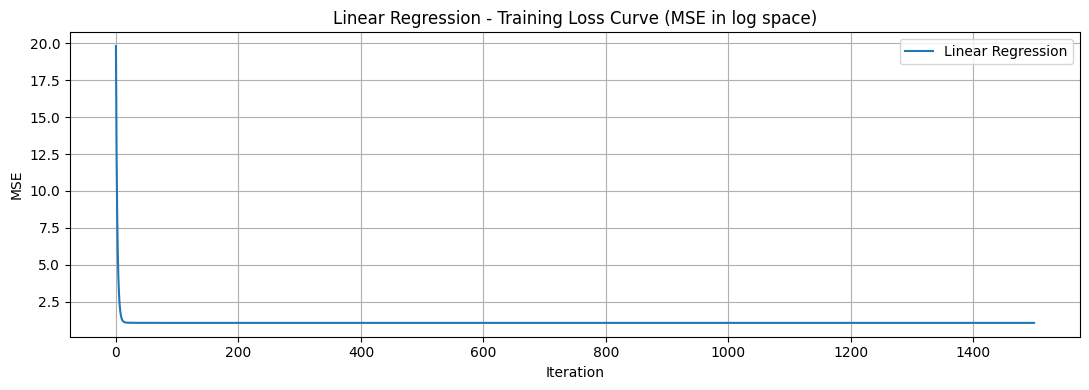

In [106]:
# ── Train Linear Regression ───────────────────────────────────────────────
lin_start  = time.time()
lin_model  = BaselineRegressionModel(learning_rate=best_lr_lin, n_iterations=1500)
lin_model.fit(X_train, Y_train_log)
lin_time   = time.time() - lin_start

lin_pred_log    = lin_model.predict(X_test)
lin_predictions = np.expm1(lin_pred_log)

print(f'Training time : {lin_time:.2f}s')
print(f'Loss          : {lin_model.loss_history[0]:.4f} -> {lin_model.loss_history[-1]:.4f}')
print(f'Converged     : {lin_model.loss_history[-1] < lin_model.loss_history[0]}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lin_model.loss_history, linewidth=1.5, label='Linear Regression')
ax.set_title('Linear Regression - Training Loss Curve (MSE in log space)')
ax.set_xlabel('Iteration'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

In [107]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [15, 15, 8, 1] means:
            - 15 input features
            - Hidden layer 1: 15 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)

        Store in self.parameters dictionary
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            #  Initialize weights and biases
            self.parameters[f'W{l}'] = np.random.randn(self.architecture[l-1], self.architecture[l]) * 0.01

            self.parameters[f'b{l}'] = np.zeros((1, self.architecture[l]))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])

        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        self.cache['A0'] = X
        A = X

        for l in range(1, len(self.architecture)):
            W_l = self.parameters[f'W{l}']
            b_l = self.parameters[f'b{l}']

            Z_l = np.dot(A, W_l) + b_l
            self.cache[f'Z{l}'] = Z_l

            if l < len(self.architecture) - 1:
                A = self.relu(Z_l)
            else:
                A = Z_l
            self.cache[f'A{l}'] = A

        return A

    def backward_propagation(self, X, y):
        """
        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m

        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}

        y_reshaped = y.reshape(-1, 1)
        num_layers = len(self.architecture) - 1
        A_L = self.cache[f'A{num_layers}']
        dZ = A_L - y_reshaped

        # Gradients for the output layer's weights and biases
        grads[f'dW{num_layers}'] = (1 / m) * np.dot(self.cache[f'A{num_layers - 1}'].T, dZ)
        grads[f'db{num_layers}'] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

        # Propagate gradients backwards through hidden layers
        for l in range(num_layers - 1, 0, -1):
            W_l_plus_1 = self.parameters[f'W{l+1}']  # Weights of the next layer (in forward direction)
            dA = np.dot(dZ, W_l_plus_1.T)
            dZ = dA * self.relu_derivative(self.cache[f'Z{l}'])

            # Gradients for current layer's weights and biases
            grads[f'dW{l}'] = (1 / m) * np.dot(self.cache[f'A{l-1}'].T, dZ)
            grads[f'db{l}'] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

        return grads

    def update_parameters(self, grads):
        """
        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        num_layers = len(self.architecture) - 1
        for l in range(1, num_layers + 1):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):

        m = y_true.shape[0]
        loss = (1 / (2 * m)) * np.sum((y_pred - y_true.reshape(-1, 1)) ** 2)
        return loss

    def fit(self, X, y):

        self.initialize_parameters()

        for i in range(self.n_iterations):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
            self.loss_history.append(loss)

        return self

    def predict(self, X):

        y_pred = self.forward_propagation(X)

        return y_pred.flatten()

In [110]:
# ── LR sweep (MLP) ────────────────────────────────────────────────────────
print('Learning rate sweep -- MLP (200 iters):')
print(f'{"LR":<10} {"Start loss":>12} {"End loss":>12}')
print('-' * 36)
best_lr_mlp, best_end_mlp = 0.01, np.inf
for test_lr in [0.001, 0.005, 0.01, 0.05]:
    np.random.seed(42)
    n_in = X_train.shape[1]
    W1 = np.random.randn(n_in, 64) * np.sqrt(2.0/n_in)
    b1 = np.zeros((1,64))
    W2 = np.random.randn(64,32)   * np.sqrt(2.0/64)
    b2 = np.zeros((1,32))
    W3 = np.random.randn(32,16)   * np.sqrt(2.0/32)
    b3 = np.zeros((1,16))
    W4 = np.random.randn(16,1)    * np.sqrt(2.0/16)
    b4 = np.zeros((1,1))
    losses = []
    for _ in range(200):
        A1=np.maximum(0,np.dot(X_train,W1)+b1)
        A2=np.maximum(0,np.dot(A1,W2)+b2)
        A3=np.maximum(0,np.dot(A2,W3)+b3)
        A4=np.dot(A3,W4)+b4
        loss=float(np.mean((A4.flatten()-Y_train_log)**2)/2)
        losses.append(loss)
        if np.isnan(loss): break
        m=len(Y_train_log)
        dZ4=(A4-Y_train_log.reshape(-1,1))/m
        dW4=np.clip(np.dot(A3.T,dZ4),-5,5)
        dZ3=np.dot(dZ4,W4.T)*(A3>0); dW3=np.clip(np.dot(A2.T,dZ3),-5,5)
        dZ2=np.dot(dZ3,W3.T)*(A2>0); dW2=np.clip(np.dot(A1.T,dZ2),-5,5)
        dZ1=np.dot(dZ2,W2.T)*(A1>0); dW1=np.clip(np.dot(X_train.T,dZ1),-5,5)
        W4-=test_lr*dW4; b4-=test_lr*np.sum(dZ4,axis=0,keepdims=True)
        W3-=test_lr*dW3; b3-=test_lr*np.sum(dZ3,axis=0,keepdims=True)
        W2-=test_lr*dW2; b2-=test_lr*np.sum(dZ2,axis=0,keepdims=True)
        W1-=test_lr*dW1; b1-=test_lr*np.sum(dZ1,axis=0,keepdims=True)
    end = losses[-1] if losses and not np.isnan(losses[-1]) else np.inf
    print(f'{test_lr:<10} {losses[0]:>12.4f} {end:>12.4f}')
    if end < best_end_mlp:
        best_end_mlp = end; best_lr_mlp = test_lr
print(f'Chosen LR: {best_lr_mlp}')

Learning rate sweep -- MLP (200 iters):
LR           Start loss     End loss
------------------------------------
0.001           10.9359       1.9216
0.005           10.9359       0.8266
0.01            10.9359       0.6720
0.05            10.9359       0.5483
Chosen LR: 0.05


In [112]:
mlp_start = time.time()
mlp_arch  = [X_train.shape[1], 32, 16, 1]
mlp_model = MLP(architecture=mlp_arch, learning_rate=best_lr_mlp,
                n_iterations=2000, clip=5.0)
mlp_model.fit(X_train, Y_train_log, verbose_every=400)
mlp_time  = time.time() - mlp_start

mlp_pred_log    = mlp_model.predict(X_test)
mlp_predictions = np.expm1(mlp_pred_log)

print(f'Training time : {mlp_time:.2f}s')
print(f'Loss          : {mlp_model.loss_history[0]:.5f} -> {mlp_model.loss_history[-1]:.5f}')
print(f'Converged     : {mlp_model.loss_history[-1] < mlp_model.loss_history[0]}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mlp_model.loss_history, color=PALETTE[1], linewidth=1.5, label='MLP')
ax.set_title('MLP - Training Loss Curve (MSE in log space)')
ax.set_xlabel('Iteration'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('loss_mlp.png', dpi=130, bbox_inches='tight', facecolor='#0f1117')
plt.show()

TypeError: MLP.__init__() got an unexpected keyword argument 'clip'

In [108]:
import time

print("Training MLP...")

Y_train = Y_train.values.reshape(-1, 1)
Y_test = Y_test.values.reshape(-1, 1)

# Start timer BEFORE training
mlp_start_time = time.time()

# Define model
mlp_architecture = [X_train.shape[1], 32, 16, 8, 1]
mlp_model = MLP(
    architecture=mlp_architecture,
    learning_rate=0.001,   # better than 0.01
    n_iterations=1000
)

# Train
mlp_model.fit(X_train, Y_train)

# Predictions
mlp_predictions = mlp_model.predict(X_test)

# End timer
mlp_training_time = time.time() - mlp_start_time

# Output
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...


AttributeError: 'numpy.ndarray' object has no attribute 'values'